In [2]:
print('hello world')

hello world


In [ ]:
# Only run this is the merged whine_data is not available for some reason

import pandas as pd
import os

notebook_dir = os.getcwd() 
# Paths to files - use raw strings or double backslashes
csv_path_red = os.path.join(notebook_dir, '..', 'data', 'winequality-red.csv')
csv_path_white = os.path.join(notebook_dir, '..', 'data', 'winequality-white.csv')
out_path = os.path.join(notebook_dir, '..', 'data', 'wine_data.xlsx')


# Read with explicit engine (openpyxl) and handle errors
df_white = pd.read_csv(csv_path_white, delimiter=";")
df_white["color"] = "white"

df_red = pd.read_csv(csv_path_red, delimiter=";")
df_red["color"] = "red"

data = pd.concat([df_red, df_white], axis=0, ignore_index=True)
data.to_excel(out_path, index=False)



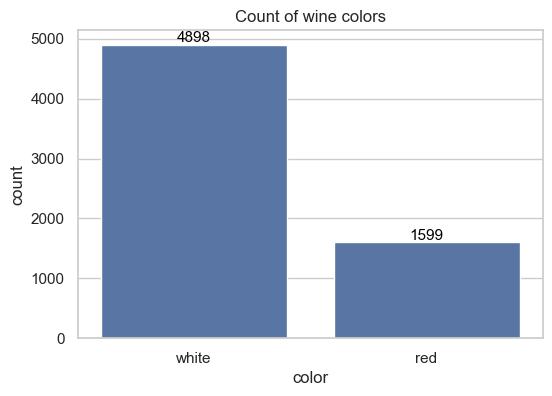

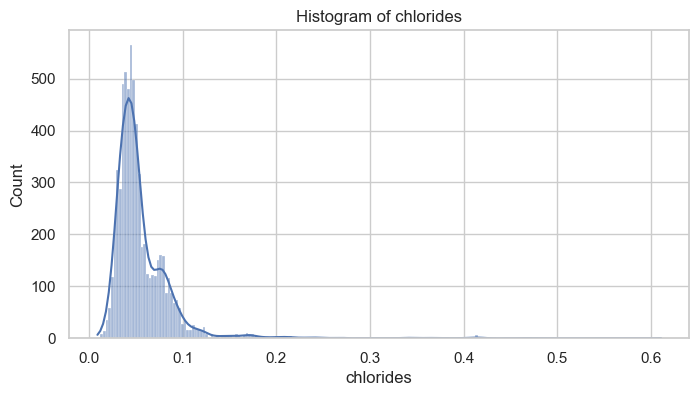

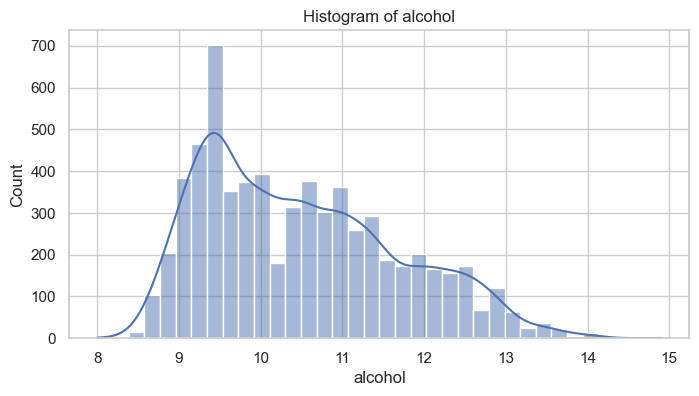

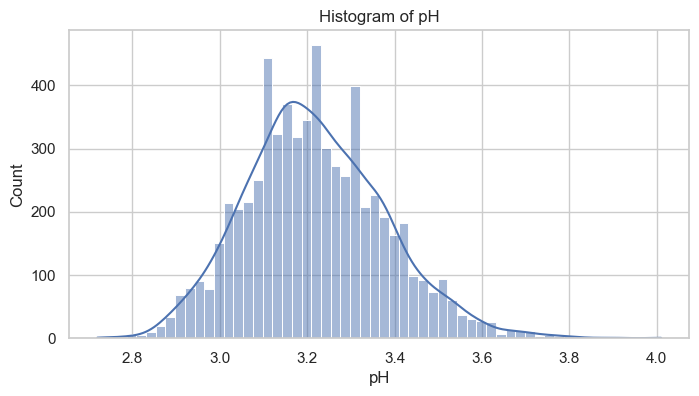

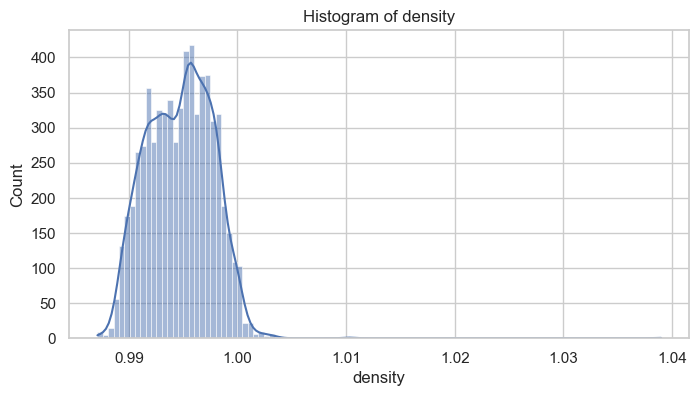

              n  n_outliers  pct_outliers  lower_bound  upper_bound
chlorides  6497         286         4.402    -0.002500     0.105500
alcohol    6497           3         0.046     6.800000    14.000000
pH         6497          73         1.124     2.795000     3.635000
density    6497           3         0.046     0.985365     1.003965


In [ ]:
# EDA: limited columns (use plt.show() instead of display)
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = os.getcwd()  
combined_path = os.path.join(notebook_dir, '..', 'data', 'wine_data.xlsx')
data = pd.read_excel(combined_path, engine="openpyxl")

# Plot count of wine types (red vs white)
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=data, x='color', order=['white','red'], ax=ax)
ax.set_title('Count of wine colors')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Use only the selected columns
numeric_cols = ['chlorides','alcohol','pH','density']

outlier_summary = {}

for col in numeric_cols:
    series = data[col].dropna()

    # Histogram
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(series, kde=True, ax=ax)
    ax.set_title(f'Histogram of {col}')
    plt.show()
    
    # IQR outliers
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    pct_outliers = n_outliers / len(series) * 100

    outlier_summary[col] = {
        'n': int(len(series)),
        'n_outliers': int(n_outliers),
        'pct_outliers': float(round(pct_outliers,3)),
        'lower_bound': float(lower),
        'upper_bound': float(upper)
    }

# Display summary as DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
print(outlier_df)


Dataset shape: (683, 36)
['date', 'plant-stand', 'precip', 'temp', 'hail', 'crop-hist', 'area-damaged', 'severity', 'seed-tmt', 'germination', 'plant-growth', 'leaves', 'leafspots-halo', 'leafspots-marg', 'leafspot-size', 'leaf-shread', 'leaf-malf', 'leaf-mild', 'stem', 'lodging', 'stem-cankers', 'canker-lesion', 'fruiting-bodies', 'external-decay', 'mycelium', 'int-discolor', 'sclerotia', 'fruit-pods', 'fruit-spots', 'seed', 'mold-growth', 'seed-discolor', 'seed-size', 'shriveling', 'roots', 'class']
Total missing cells: 0 (0.00%)

Top columns by missing count:
date           0
plant-stand    0
precip         0
temp           0
hail           0
dtype: int64

Per-column summary (first 50 rows shown):
         column  n_missing  pct_missing  n_unique                                                                       top3
           date          0          0.0         8                          {b'september': 149, b'august': 131, b'july': 118}
    plant-stand          0          0.0 

C:\Users\PC\AppData\Local\Temp\ipykernel_27308\2431307438.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['class'], order=df['class'].value_counts().index, palette='viridis')


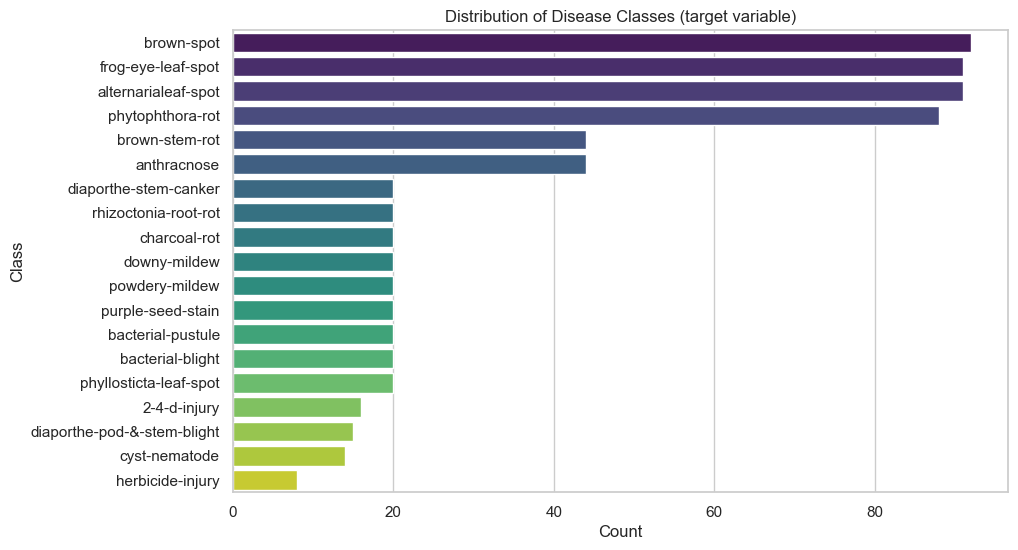

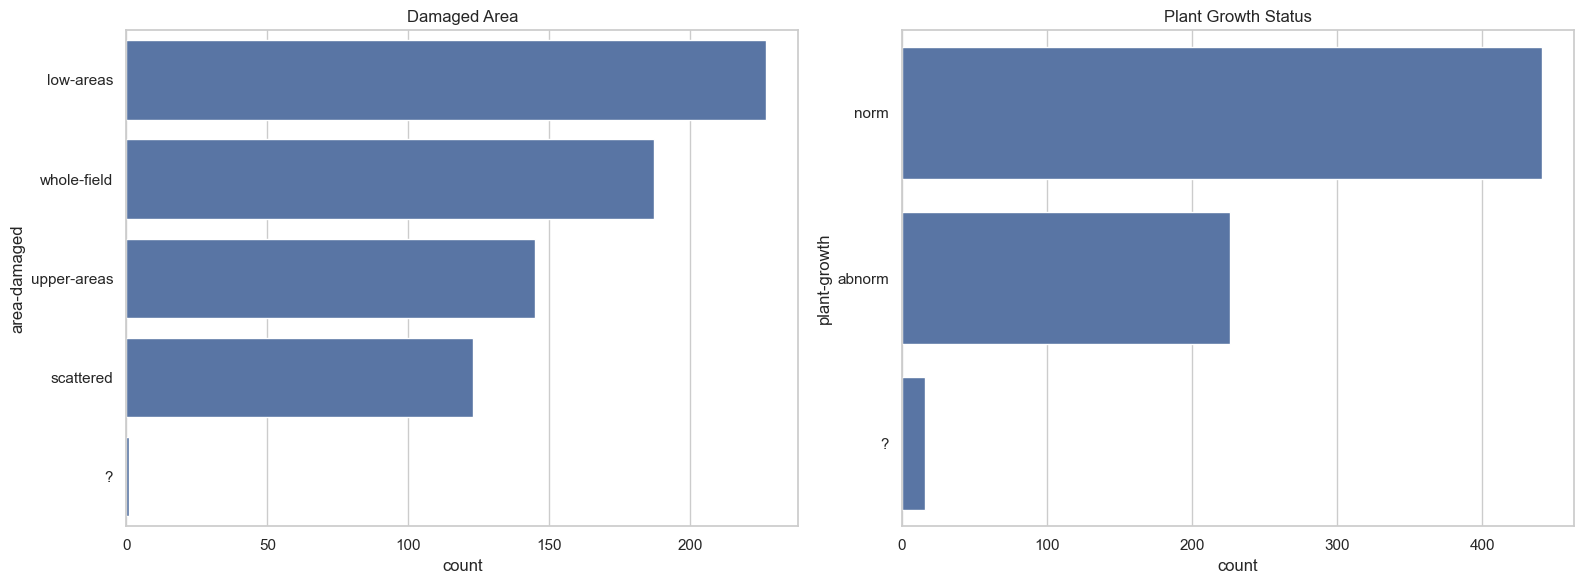

In [3]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

notebook_dir = os.getcwd()
arff_path = os.path.join(notebook_dir, '..', 'data', 'dataset_soybean.arff')


with open(arff_path, 'r') as f:
    arff_data, meta = arff.loadarff(f)
cols = meta.names()
df = pd.DataFrame(arff_data, columns=cols)

# Concise textual summary
print(f"Dataset shape: {df.shape}")
print(df.columns.tolist())

total_cells = df.size
total_missing = df.isna().sum().sum()
print(f"Total missing cells: {int(total_missing)} ({total_missing/total_cells*100:.2f}%)")

# Top 5 columns by missing count
missing_counts = df.isna().sum()
print("\nTop columns by missing count:")
print(missing_counts.sort_values(ascending=False).head(5))

# Per-column compact summary: n_missing, pct_missing, n_unique, top3
summary = []
for c in df.columns:
    s = df[c]
    n_missing = int(s.isna().sum())
    pct_missing = n_missing / len(s) * 100
    n_unique = int(s.nunique(dropna=True))
    top3 = s.value_counts(dropna=True).head(3).to_dict()
    summary.append((c, n_missing, round(pct_missing,3), n_unique, top3))

summary_df = pd.DataFrame(summary, columns=['column','n_missing','pct_missing','n_unique','top3'])
# Print only first 30 rows for compactness
pd.set_option('display.max_rows', 200)
print("\nPer-column summary (first 50 rows shown):")
print(summary_df.head(50).to_string(index=False))


# Distribution of Target and Key Features
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.countplot(y=df['class'], order=df['class'].value_counts().index, palette='viridis')
plt.title('Distribution of Disease Classes (target variable)')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()


# 2) Key environmental features plot: area-damaged and plant-growth
fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.countplot(ax=axes[0], y=df['area-damaged'], order=df['area-damaged'].value_counts().index)
axes[0].set_title('Damaged Area')
sns.countplot(ax=axes[1], y=df['plant-growth'], order=df['plant-growth'].value_counts().index)
axes[1].set_title('Plant Growth Status')

plt.tight_layout()
plt.show()


